In [26]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from multiprocessing import Process
import multiprocessing
import time

In [27]:
def Greedy_policy(pkt_prob, e_prob, weight_prob, T_val, send_end):
    M = 2
    h_bad = 0.5
    h1_prob = [h_bad, (1-h_bad)]
    h_val = [0.1, 1]
    B_max = 2
    rmax = 1
    B_prev1 = 0
    B_prev2 = 0
    rem_prev1 = 0
    rem_prev2 = 0
    wt_start1 = 1
    wt_start2 = 1
    opt_sol = 0
    for t in range(T_val):
        # if t%1000 == 0:
        #     print('itr', t)
        wt1 = np.random.choice([1, 2], p = [weight_prob, (1-weight_prob)])
        wt2 = np.random.choice([1, 2], p = [weight_prob, (1-weight_prob)])
        h1= np.random.choice([0.1, 1], p = h1_prob)
        h2= np.random.choice([0.1, 1], p = h1_prob)
        pkt1 = np.random.choice([1, 0], p=[pkt_prob, (1 - pkt_prob)])
        pkt2 = np.random.choice([1, 0], p=[pkt_prob, (1 - pkt_prob)])
        E1 = np.random.choice([1, 0], p=[ e_prob, (1-e_prob)])
        E2 = np.random.choice([1, 0], p=[ e_prob, (1-e_prob)])

        B_start1 = np.minimum(B_prev1+E1, B_max)
        B_start2 = np.minimum(B_prev2+E2, B_max)

        if pkt1 == 1:
            wt_start1 = wt1
            rem_start1 = rmax
        else:
            rem_start1 = rem_prev1

        if pkt2 == 1:
            wt_start2 = wt2
            rem_start2 = rmax
        else:
            rem_start2 = rem_prev2

        rho1 = cp.Variable(nonneg=True)
        P1 = cp.Variable(nonneg=True)
        obj_fn1 = wt_start1 * cp.exp(-(rmax - (rem_start1 - rho1))) + wt_start2 * np.exp(-(rmax - (rem_start2)))
        constraints1 = [P1 >= 0, rho1 >= 0]
        constraints1.append( P1 <= B_start1)
        constraints1.append( rho1 <= rem_start1)
        constraints1.append( rho1 <= cp.log(1 + (h1*P1) ) * cp.inv_pos(cp.log(2)) )
        constraints1.append(P1 <= (cp.exp(rem_start1 * cp.log(2)) -1)/h1)
        objective1 =cp.Minimize(obj_fn1)
        prob1 = cp.Problem(objective1, constraints1)
        optimal_val1 = prob1.solve(solver=cp.SCS, eps=1e-8,verbose =False)
    

        rho2 = cp.Variable(nonneg=True)
        P2 = cp.Variable(nonneg=True)
        obj_fn2 = wt_start2 * cp.exp(-(rmax - (rem_start2 - rho2))) + wt_start1 * np.exp(-(rmax - (rem_start1)))
        constraints2 = [P2 >= 0, rho2 >=0]
        constraints2.append( P2 <= B_start2)
        constraints2.append( rho1 <= rem_start1)
        constraints2.append( rho2 <= cp.log(1 + (h2*P2) ) * cp.inv_pos(cp.log(2)) )
        constraints2.append(P2 <= (cp.exp(rem_start2* cp.log(2)) -1)/h2)
        objective2 =cp.Minimize(obj_fn2)
        prob2 = cp.Problem(objective2, constraints2)
        optimal_val2 = prob2.solve(solver=cp.SCS, eps=1e-8,verbose =False)

        if optimal_val1 <= optimal_val2:  
            B_prev1 = B_start1 - P1.value
            rem_prev1 = rem_start1 - rho1.value
            B_prev2 = B_start2
            rem_prev2 = rem_start2
            opt_sol += optimal_val1 
        else:
            B_prev2 = B_start2 - P2.value
            rem_prev2 = rem_start2 - rho2.value    
            B_prev1 = B_start1
            rem_prev1 = rem_start1
            opt_sol += optimal_val2 

        B_prev1 = np.maximum(B_prev1, 0)
        B_prev2 = np.maximum(B_prev2, 0)
        rem_prev1 = np.maximum(rem_prev1, 0)
        rem_prev2 = np.maximum(rem_prev2, 0)
    mean_opt =  opt_sol / (T_val*M)
    # print('final objective', e_prob, pkt_prob, weight_prob,  mean_opt)
    print('final objective',  mean_opt)
    # print('----------------------------------------------------')
    # return mean_opt
    send_end.send(mean_opt)
# fin_res = Greedy_policy(pkt_prob=0, e_prob=0.5, weight_prob=0.5, T_val=1000, send_end=0)

In [28]:
# lambda_arr = np.arange(0, 1.1, 0.1)
# jobs = []
# pipe_list = []
# for pkt_prob in lambda_arr:
#     recv_end, send_end = multiprocessing.Pipe(False)
#     p = Process(target=Greedy_policy, args = (pkt_prob, 0.5, 0.5, 100000, send_end))
#     jobs.append(p)
#     pipe_list.append(recv_end)
# for process in jobs:
#     process.start()
# for process in jobs:
#     process.join()
# final_objective_pkt = np.array([x.recv() for x in pipe_list])

In [29]:
# plt.plot(lambda_arr, final_objective_pkt, 'o-')

In [30]:
# final_objective_pkt

In [31]:
lambda_arr = np.arange(0, 1.1, 0.1)
jobs = []
pipe_list = []
for e_prob in lambda_arr:
    recv_end, send_end = multiprocessing.Pipe(False)
    p = Process(target=Greedy_policy, args = (0.5, e_prob, 0.5, 100000, send_end))
    jobs.append(p)
    pipe_list.append(recv_end)
for process in jobs:
    process.start()
for process in jobs:
    process.join()
final_objective_energy = np.array([x.recv() for x in pipe_list])

/home/sysad/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/sysad/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/sysad/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


WARNING - large complementary slackness residual: 0.000000
WARNING - large complementary slackness residual: 0.000000
WARNING - large complementary slackness residual: 0.000000


/home/sysad/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


WARNING - large complementary slackness residual: 0.000000
WARNING - large complementary slackness residual: 0.000000
WARNING - large complementary slackness residual: 0.000000
WARNING - large complementary slackness residual: 0.000000
WARNING - large complementary slackness residual: 0.000000
final objective 0.8986981483948563
final objective 0.9529581717030928
final objective 1.4377770897890074
final objective 1.2419606090551973
final objective 0.9200149971731588
final objective 0.8847071167700881
final objective 0.8749547347753612
final objective 1.3398006336469432
final objective 1.0682350806566994
final objective 1.0026063380933983
final objective 1.1487187373267254


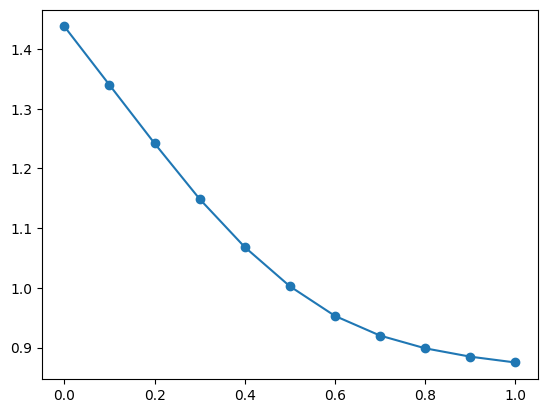

In [32]:
plt.plot(lambda_arr, final_objective_energy, 'o-')

In [45]:
final_objective_energy

array([1.43777709, 1.33980063, 1.24196061, 1.14871874, 1.06823508,
       1.00260634, 0.95295817, 0.920015  , 0.89869815, 0.88470712,
       0.87495473])

In [34]:
# lambda_arr = np.arange(0, 1.1, 0.1)
# jobs = []
# pipe_list = []
# for weight_prob in lambda_arr:
#     recv_end, send_end = multiprocessing.Pipe(False)
#     p = Process(target=Greedy_policy, args = (0.5, 0.5, weight_prob, 10000, send_end))
#     jobs.append(p)
#     pipe_list.append(recv_end)
# for process in jobs:
#     process.start()
# for process in jobs:
#     process.join()
# final_objective_weight = np.array([x.recv() for x in pipe_list])

In [35]:
# final_objective_weight

In [36]:
# plt.plot(lambda_arr, final_objective_weight, 'o-')

In [37]:
# import pandas as pd

# df = pd.DataFrame({
#     "lambda": lambda_arr,
#     "pkt": final_objective_pkt,
#     "energy": final_objective_energy,
#     "weight": final_objective_weight
# })

# # Save to CSV
# df.to_csv("greedy_noma.csv", index=False)

In [38]:
h = 1
P1 = 2
P2 = 2
np.log2(1 + h*P1 + h*P2)

2.321928094887362

In [39]:
(3**2)*(3**2)*(2**2)*(2**2)

1296

In [40]:
(3**3)*(3**3)*(2**3)*(2**3)

46656

In [41]:

(3**4)*(3**4)*(2**4)*(2**4)

1679616

In [42]:
# import pandas as pd

# # Read the CSV file into a DataFrame
# df = pd.read_csv("greedy_noma.csv")

# # Convert each column to a separate NumPy array by header name
# noma_pkt = df["pkt"].to_numpy()
# noma_energy = df["energy"].to_numpy()
# noma_weigh = df["weight"].to_numpy()

In [43]:
# import pandas as pd

# # Read the CSV file into a DataFrame
# df = pd.read_csv("greedy_tdma.csv")

# # Convert each column to a separate NumPy array by header name
# tdma_pkt = df["pkt"].to_numpy()
# tdma_energy = df["energy"].to_numpy()
# tdma_weigh = df["weight"].to_numpy()

In [44]:
# lambda_arr = np.arange(0, 1.1, 0.1)
# plt.plot(lambda_arr, noma_pkt, 'o-')
# plt.plot(lambda_arr, tdma_pkt, 's-')